# Test Filesystem Indexation

**Living Earth - Cube in a Box Tools Series**

---

*   **Objective:** Verify and explore data indexed from local storage into the datacube.
*   **Products used:** Just indexed by user
*   **Source:** [CiaB Explorer](http://localhost/explorer/products)

---

## Background

Indexation of new local products using [STAC_to_fs.ipynb](STAC_to_fs.ipynb) need to be tested.

## Description

This notebook provides tools for testing if local data was correctly indexed and allows interactive AOI exploration.

***

In [1]:
import sys
sys.path.insert(1, '../utils/')

In [ ]:
import datacube
import rioxarray
import time

from IPython.display import HTML, display

from utils.deafrica_plotting import rgb
from utils.le_dc import get_product_bbox
from utils.le_mapping import bbox_to_polygon, display_crosshair, get_utm_epsg_code, MapHandler
from utils.le_tools import style_output_cells

In [3]:
dc = datacube.Datacube(app="Test_MinIO_indexation")

In [4]:
# Check if default bbox is contained within the datacube
# and allow user to draw bbox if not.

product = 'ls89_c2l2_sp_local'

product_bbox = get_product_bbox(dc, product, split_size=10, stability_threshold=4)

In [5]:
# Create an instance of MapHandler
map_handler = MapHandler()
m, drc = map_handler.create_map(vect=[bbox_to_polygon(product_bbox)],
                               draw_rect=True)
display(m)

# append crosshair
time.sleep(2)  # make sure m is fully displayed
display_crosshair()

Map(center=[46.016623614450374, 6.644603170482554], controls=(AttributionControl(options=['position', 'prefix'…

<IPython.core.display.Javascript object>

In [6]:
# Warn in case of full AoI
aoi_poly = map_handler.aoi_tupple

if aoi_poly is None:
    style_output_cells('salmon', border_color='red', border_width='2px')
    print('The area of interest polygon (aoi_poly) has not been created. Please draw it in the previous cell.')
else:
    # A polygon was drawn
    style_output_cells()
    print('Custom area of interest polygon has been created.')

Custom area of interest polygon has been created.


In [7]:
# get EPSG code for the center of the AoI

epsg_code = get_utm_epsg_code((aoi_poly[1] + aoi_poly[3]) / 2, (aoi_poly[0] + aoi_poly[2]) / 2)

In [8]:
dss = dc.find_datasets(product=product,
                       x=(aoi_poly[0], aoi_poly[2]),
                       y=(aoi_poly[1], aoi_poly[3]))
times = [ds.time.begin for ds in dss]
start_date = min(times)
end_date = max(times)

In [9]:
lazy_ds = dc.load(product=product,
                  measurements=['red', 'green', 'blue'],
                  output_crs=f"EPSG:{epsg_code}",
                  y=(aoi_poly[1], aoi_poly[3]),
                  x=(aoi_poly[0], aoi_poly[2]),
                  time=(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
                  resolution=30,
                  group_by="solar_day",
                  dask_chunks={},
                  )
lazy_ds.rio.write_crs(f"EPSG:{epsg_code}", inplace=True)  # NotGeoreferencedWarning fix

<xarray.Dataset> Size: 257kB
Dimensions:      (time: 2, y: 138, x: 154)
Coordinates:
  * time         (time) datetime64[ns] 16B 2024-07-21T10:16:29.731228 2024-07...
  * y            (y) float64 1kB 5.152e+06 5.152e+06 ... 5.148e+06 5.148e+06
  * x            (x) float64 1kB 4.006e+05 4.007e+05 ... 4.052e+05 4.052e+05
    spatial_ref  int64 8B 0
Data variables:
    red          (time, y, x) uint16 85kB dask.array<chunksize=(1, 138, 154), meta=np.ndarray>
    green        (time, y, x) uint16 85kB dask.array<chunksize=(1, 138, 154), meta=np.ndarray>
    blue         (time, y, x) uint16 85kB dask.array<chunksize=(1, 138, 154), meta=np.ndarray>

In [10]:
# customized chunking is less buggy when performed after loading !!!
lazy_ds = lazy_ds.chunk({"x": 512, "y": 512, "time": 1})
print(lazy_ds)

<xarray.Dataset> Size: 257kB
Dimensions:      (time: 2, y: 138, x: 154)
Coordinates:
  * time         (time) datetime64[ns] 16B 2024-07-21T10:16:29.731228 2024-07...
  * y            (y) float64 1kB 5.152e+06 5.152e+06 ... 5.148e+06 5.148e+06
  * x            (x) float64 1kB 4.006e+05 4.007e+05 ... 4.052e+05 4.052e+05
    spatial_ref  int64 8B 0
Data variables:
    red          (time, y, x) uint16 85kB dask.array<chunksize=(1, 138, 154), meta=np.ndarray>
    green        (time, y, x) uint16 85kB dask.array<chunksize=(1, 138, 154), meta=np.ndarray>
    blue         (time, y, x) uint16 85kB dask.array<chunksize=(1, 138, 154), meta=np.ndarray>


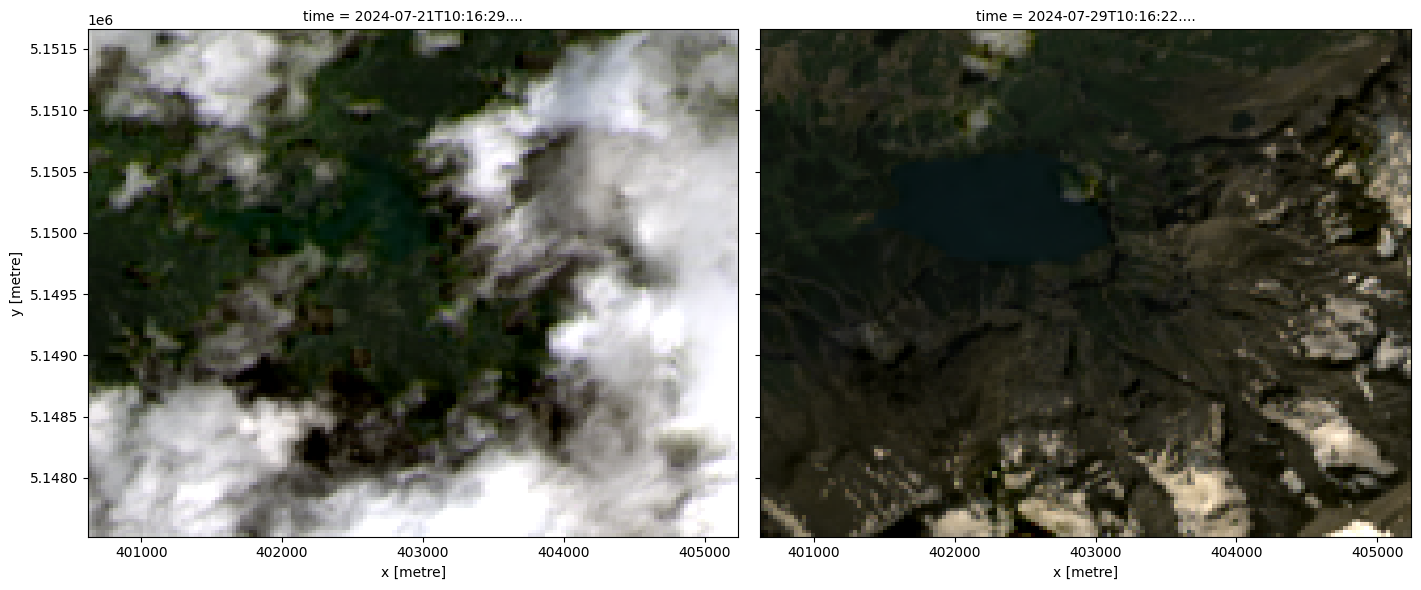

In [11]:
rgb(lazy_ds, col="time", col_wrap=4, robust=True)

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [12]:
print(datacube.__version__)

1.9.13


**Last tested:**

In [13]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-02-24'

In [14]:
!pip freeze

affine==2.4.0
ai-edge-litert==2.1.2
aiobotocore==3.1.1
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aioitertools==0.13.0
aiosignal==1.4.0
alembic==1.18.3
annotated-types==0.7.0
antimeridian==0.4.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.1.0
attrs==25.4.0
babel==2.18.0
backports.strenum==1.2.8
beautifulsoup4==4.14.3
bleach==6.3.0
bokeh==3.8.2
boltons==25.0.0
boto3==1.42.30
botocore==1.42.30
branca==0.8.2
cachetools==7.0.0
cattrs==25.3.0
certifi==2026.1.4
certipy==0.2.2
cffi==2.0.0
cftime==1.6.5
charset-normalizer==3.4.4
ciso8601==2.3.3
click==8.1.8
click-plugins==1.1.1.2
cligj==0.7.2
cloudpickle==3.1.2
comm==0.2.3
contourpy==1.3.3
cryptography==46.0.4
cycler==0.12.1
dask==2025.7.0
dask-image==2025.11.0
dask_labextension==7.0.0
datacube==1.9.13
datadog==0.52.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
deprecat==2.1.3
distributed==2025.7.0
eodatasets3==1.9.3
executing==2.2.1
fastjsonschema==2.21.2
fiona==1.10.1
flatbuff